# Projet ML — Prédiction de la direction du Bitcoin

**Cours :** Introduction au Machine Learning — L3 Dauphine  
**Auteurs :** Antoine Maurange, Iséo Guilhot-Gaudeffroy, Enzo Zhang, Bastien Marbaud

---

## 1. Présentation du projet

Les cryptomonnaies, notamment le Bitcoin, sont des actifs très volatils dont l'évolution dépend de nombreux facteurs (sentiment de marché, actualités, flux de capitaux, etc.). Une question naturelle est de savoir si l'on peut, à partir uniquement de l'historique des prix et des volumes, prédire une hausse ou une baisse du prix.

### Problématique
**Peut-on prédire si le cours du Bitcoin va monter ou baisser à partir de variables construites sur son historique récent ?**

### Définition du problème

D'abord il est nécessaire de définir précisément ce qui est entendu par "prédire le cours du bitcoin". Notre objectif est de savoir à un jour $t$, s'il est intéressant d'acheter ou de vendre. Pour cela on aimerait prédire si le cours va augmenter ou diminuer.

Nous considérerons que d'un jour $t$ à un jour $(t+1)$ le cours du Bitcoin augmente (resp diminue) si sa valeur à la clôture au jour $t$ est inférieure (resp supérieure) à sa valeur à la clôture au jour $(t+1)$. 


Il s'agit d'un problème de **classification binaire supervisée** :
- $X$ : ensemble de variables (rendements passés, moyennes mobiles, volatilité, volume…) calculées au jour $t$. On expliquera plus tard pourquoi ce choix de données
- $y \in \{0, 1\}$ : 1 si $\text{Close}_{t+1} > \text{Close}_{t}$ (hausse), 0 sinon (baisse)

### Données
Dataset Kaggle : *Bitcoin Historical Datasets 2018-2024* (Novandra Anugrah).  
Lien : https://www.kaggle.com/datasets/novandraanugrah/bitcoin-historical-datasets-2018-2024

Nous utilisons le fichier **journalier** (`btc_1d_data_2018_to_2025.csv`) qui contient les colonnes Open, High, Low, Close, Volume de la pool BTC/USDT sur Binance depuis 2018.

### Étapes du projet
1. Exploration et nettoyage des données
2. Construction de variables 
3. Visualisation par ACP
4. Comparaison de plusieurs modèles : régression logistique, régression logistique pénalisée (Ridge / Lasso) et KNN
5. Choix du modèle final par validation croisée
6. Évaluation sur un jeu de test chronologique
7. Test de généralisation sur d'autres cryptomonnaies (ETH, SOL)
8. Discussion et perspectives

## 2. Imports et configuration

In [350]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

np.random.seed(42) 

## 3. Chargement et exploration des données

Le dataset contient une ligne par jour avec les prix d'ouverture, plus haut, plus bas, de clôture et le volume échangé.

In [351]:
DATA_PATH = "data/btc_1d_data_2018_to_2025.csv"

df = pd.read_csv(DATA_PATH)

# Conversion de la date et tri chronologique
df['Open time'] = pd.to_datetime(df['Open time'])
df = df.sort_values('Open time').reset_index(drop=True)

#on ne garde que les colonnes utiles
df = df[['Open time', 'Open', 'High', 'Low', 'Close', 'Volume']]
df = df.rename(columns={'Open time': 'Date'})

df.head()

,Date,Open,High,Low,Close,Volume
0,2018-01-01 00:00:00+00:00,13715.65,13818.55,12750.00,13380.00,8609.915844
1,2018-01-02 00:00:00+00:00,13382.16,15473.49,12890.02,14675.11,20078.092111
2,2018-01-03 00:00:00+00:00,14690.00,15307.56,14150.00,14919.51,15905.667639
3,2018-01-04 00:00:00+00:00,14919.51,15280.00,13918.04,15059.54,21329.649574
4,2018-01-05 00:00:00+00:00,15059.56,17176.24,14600.00,16960.39,23251.491125


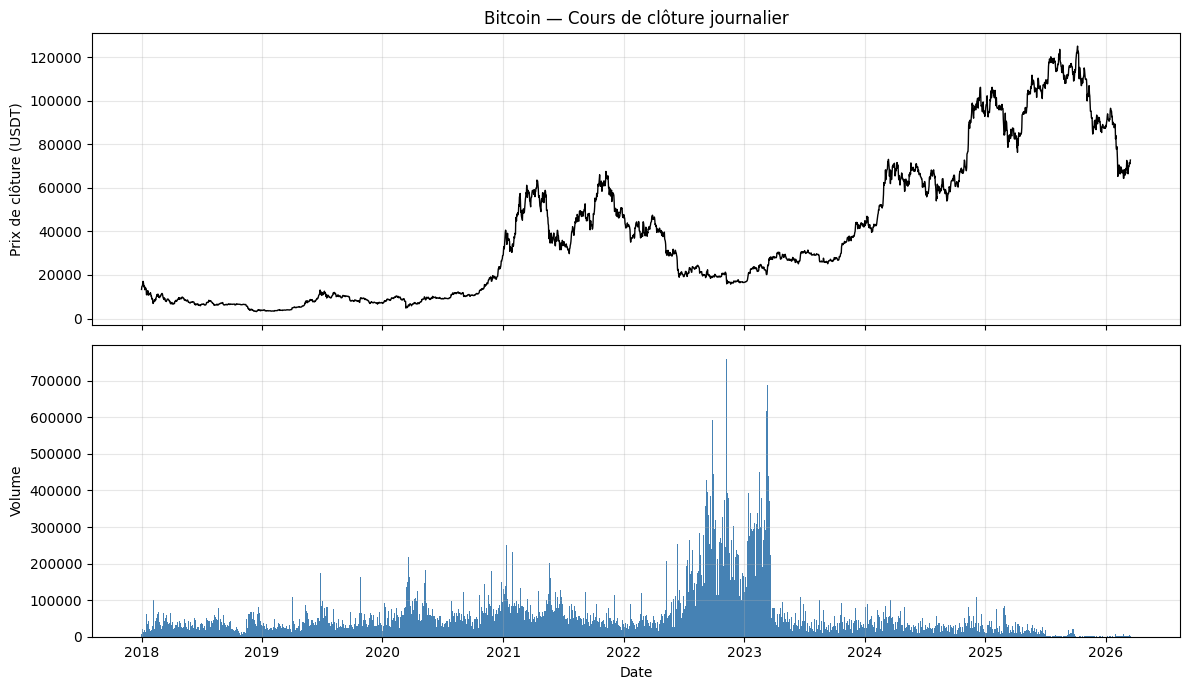

In [352]:
# Visualisation du cours de clôture et du volume
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df['Date'], df['Close'], color='black', lw=1)
axes[0].set_ylabel("Prix de clôture (USDT)")
axes[0].set_title("Bitcoin — Cours de clôture journalier")
axes[0].grid(alpha=0.3)

axes[1].bar(df['Date'], df['Volume'], color='steelblue', width=1.0)
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

(*On observe les grandes phases du marché : la bulle de fin 2017, le bear market de 2018, le rallye 2020-2021, le crash 2022, puis la reprise. C'est typique d'une série financière : **non stationnaire**, avec de forts changements de régime*)

**Remarques sur les fluctuations du volume 2022-2023**

On note une explosion du volume sur Binance autour de 2022-2023, suivie d'une chute assez nette. Plusieurs facteurs l'expliquent :

- En 2022, Binance a supprimé les frais de transaction sur certaines paires, ce qui a mécaniquement boosté les échanges, notamment via des robots de trading.
- Le crash de la platforme concurente FTX fin 2022 a provoqué un rapatriement massif des capitaux vers Binance, perçu comme plus solide.
- La faillite de plusieurs banques américaines début 2023 (Silicon Valley Bank, Signature Bank...) a poussé certains investisseurs à se tourner vers le Bitcoin comme valeur refuge.

La chute du volume après 2023 s'explique en partie par la fragmentation du marché : de nombreux concurrents ont émergé, et d'autres pools sur Binance (comme BTC/USDC) ont capté une part croissante des échanges. Le volume sur la seule pool BTC/USDT n'est donc plus très représentatif de l'activité globale sur le Bitcoin à partir de cette période.

## 4. Feature engineering

Dans ce contexte, donner directement le prix brut au modèle n'a pas vraiment de sens. Un prix de 10 000$ en 2020 et un prix de 10 000$ en 2023 ne représentent pas du tout la même situation de marché.

L'idée est donc de construire des variables qui effacent cette barrière temporelle : plutôt que de regarder *où* est le prix, on regarde *comment il se comporte*. Ses variations récentes, son écart à sa propre tendance, sa volatilité. Ce sont des grandeurs relatives, comparables d'une période à l'autre, que le marché soit à 5 000$ ou à 60 000$.

### Variables construites

On a retenu des variables classiques en finance quantitative.

**Rendements passés** (variations relatives) :
$$r_t = \frac{\text{Close}_t - \text{Close}_{t-1}}{\text{Close}_{t-1}}$$
La variation du prix en % sur la journée. On la calcule sur plusieurs fenêtres : $r_{t-1}, r_{t-2}, r_{t-5}, r_{t-10}$ pour capturer différents horizons de tendance.

**Moyennes mobiles MA20 et écart relatif** au MA20 :
$$\text{ecart\_MA20}_t = \frac{\text{Close}_t - \text{MA20}_t}{\text{MA20}_t}$$
Cet écart dit si le prix est anormalement haut ou bas par rapport à sa tendance des 20 derniers jours. 

**Volatilité réalisée** (sur 5,10,20 jours) :
$$\sigma_{N,t} = \sqrt{\frac{1}{N-1} \sum_{i=0}^{N-1} (r_{t-i} - \bar{r}_{N,t})^2}$$
*(Où $\bar{r}_{N,t}$ est la moyenne arithmétique des rendements sur la fenêtre de $N$ jours).*

C'est simplement l'écart-type des rendements sur une période fixée. Elle donne une idée du régime actuel du marché, calme ou agité. Un modèle peut potentiellement se comporter différemment selon la volatilité ambiante.

**Volume normalisé** :
$$\text{vol\_norm}_t = \frac{V_t}{\text{MA20}_{V,t}}$$

On ne peut pas utiliser le volume brut directement pour les mêmes raisons que le prix : il a explosé entre 2018 et 2023 avant de chuter, ce qui le rend non comparable dans le temps. On le normalise donc par sa moyenne mobile sur 20 jours. Un ratio > 1 signifie que le volume du jour est au-dessus de la normale, < 1 en dessous. L'idée est qu'un mouvement de prix qui s'accompagne d'un volume fort a plus de chances d'être réel qu'un mouvement sur un volume faible.

**Cible (Target)** :
$$y_t = \begin{cases} 1 & \text{si } \text{Close}_{t+1} > \text{Close}_t \\ 0 & \text{sinon} \end{cases}$$

In [353]:
def construire_features(df):
    data = df.copy()
    
    # Rendements (variations relatives) du prix de clôture
    data['return_1'] = data['Close'].pct_change(1) #calcul variation en pourcentage entre le close de la veille et 
    data['return_2'] = data['Close'].pct_change(2)
    data['return_5'] = data['Close'].pct_change(5)
    data['return_10'] = data['Close'].pct_change(10)
    
    # Moyenne mobiles
    data['MA20'] = data['Close'].rolling(20).mean()
    
    # Écart relatif du prix actuel à sa moyenne mobile 20j
    data['ecart_MA20'] = (data['Close'] - data['MA20']) / data['MA20']
    
    # Volatilité réalisée (std des rendements journaliers)
    data['vol_5'] = data['return_1'].rolling(5).std()
    data['vol_20'] = data['return_1'].rolling(20).std()
    
    # Volume normalisé par sa moyenne mobile 20j
    data['vol_norm'] = data['Volume'] / data['Volume'].rolling(20).mean()
    
    # Cible : 1 si le prix monte demain, 0 sinon
    data['y'] = (data['Close'].shift(-1) > data['Close']).astype(int)
    
    return data

df_feat = construire_features(df)

#liste des features que l'on va utiliser pour entrainer le modèle
#liste des features que l'on va utiliser pour entrainer le modèle
FEATURES = [
    'return_1', 'return_2', 'return_5', 'return_10',
    'ecart_MA20',
    'vol_5', 'vol_20',
    'vol_norm',
]

#on enlève les premières lignes où les fenêtres glissantes ne sont pas encore définies
# et la dernière ligne où y n'est pas défini (pas de jour suivant)
df_clean = df_feat.dropna(subset=FEATURES + ['y']).reset_index(drop=True)

print(f"Nombre d'observations après nettoyage : {len(df_clean)}")
print(f"Nombre de features : {len(FEATURES)}")
df_clean[['Date', 'Close'] + FEATURES + ['y']].head()

Nombre d'observations après nettoyage : 2977
Nombre de features : 8


,Date,Close,return_1,return_2,return_5,return_10,ecart_MA20,vol_5,vol_20,vol_norm,y
0,2018-01-21 00:00:00+00:00,11530.00,-0.099215,0.004795,0.057798,-0.129074,-0.164200,0.078251,0.078759,1.498467,0
1,2018-01-22 00:00:00+00:00,10760.05,-0.066778,-0.159367,-0.020816,-0.216882,-0.208786,0.086347,0.076152,1.519268,1
2,2018-01-23 00:00:00+00:00,10799.18,0.003637,-0.063384,-0.014850,-0.240030,-0.193694,0.086369,0.075945,1.254278,1
3,2018-01-24 00:00:00+00:00,11349.99,0.051005,0.054827,-0.010892,-0.157700,-0.140668,0.086957,0.077156,0.900235,0
4,2018-01-25 00:00:00+00:00,11175.27,-0.015394,0.034826,-0.126928,-0.174643,-0.134952,0.059037,0.070062,0.693561,0


### Sélection des features : matrice de corrélation

Avant d'entraîner les modèles, on regarde si certaines features sont très corrélées entre elles. Si c'est le cas, elles apportent la même information et on peut en supprimer sans perte.


On observe que `return_10` est très corrélé à `ecart_MA20` (0.92) et que `vol_10` est très corrélé à `vol_5` et `vol_20`. Ce sont les deux candidates à supprimer.

On a fait plusieurs tests en retirant ces variables une par une et en combinaison pour mesurer l'impact sur les modèles. Retirer `return_10` fait baisser significativement l'accuracy, notamment sur le KNN qui est le modèle qui nous donne les meilleurs résultats, on la conserve donc malgré la corrélation. En revanche, supprimer `vol_10` améliore l'accuracy du KNN, ce qui confirme qu'elle introduit du bruit redondant avec `vol_5` et `vol_20`. On la retire donc des features finales.


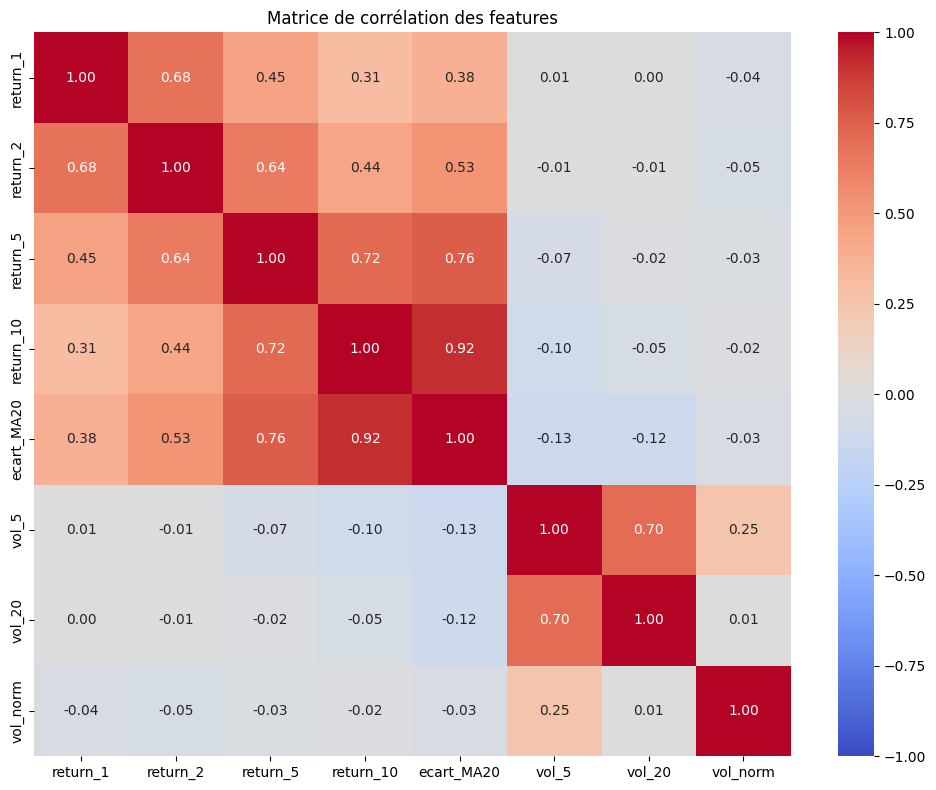

In [354]:
import seaborn as sns

corr = df_clean[FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Matrice de corrélation des features')
plt.tight_layout()
plt.show()


In [355]:
# Répartition des classes
print(df_clean['y'].value_counts(normalize=True).rename({0: 'Baisse', 1: 'Hausse'}))
print(f"\nProportion de jours en hausse : {df_clean['y'].mean():.2%}")

y
Hausse    0.50823
Baisse    0.49177
Name: proportion, dtype: float64

Proportion de jours en hausse : 50.82%


Les classes sont à peu près équilibrées avec un léger biais haussier (logique sur la période 2018-2025 où le BTC a fortement progressé). Ce léger déséquilibre nous donne **un baseline naïf** : prédire toujours "hausse" donne déjà ~52-53% d'accuracy. C'est ce score que nos modèles devront battre.

## 5. Préparation du jeu de données : split chronologique

Nous avons décidé de ne pas faire de `train_test_split` aléatoire. C'est commun lorsque l'on travaille sur des séries temporelles pour ne pas mélanger le passé et le futur (et donc faire fuiter de l'information).

On fait donc un split **chronologique** : on entraîne sur les 95% premiers jours et on teste sur les 5% les plus récents.

In [356]:
X = df_clean[FEATURES].values
y = df_clean['y'].values
dates = df_clean['Date'].values

# Split chronologique 95/5
split_idx = int(len(df_clean) * 0.95)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train, dates_test = dates[:split_idx], dates[split_idx:]

print(f"Train : {len(X_train)} jours  ({pd.Timestamp(dates_train[0]).date()} → {pd.Timestamp(dates_train[-1]).date()})")
print(f"Test  : {len(X_test)} jours  ({pd.Timestamp(dates_test[0]).date()} → {pd.Timestamp(dates_test[-1]).date()})")

Train : 2828 jours  (2018-01-21 → 2025-10-18)
Test  : 149 jours  (2025-10-19 → 2026-03-16)


In [357]:
# Standardisation des features (moyenne 0, écart-type 1)
# Important : on fit le scaler UNIQUEMENT sur le train pour éviter la fuite d'information
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 6. Visualisation par ACP

Avant de modéliser, nous allons projeter les données grâce à une **Analyse en Composantes Principales** pour voir si les classes "hausse" et "baisse" sont visuellement séparables. Si elles ne le sont pas, c'est déjà un indice que la tâche est difficile.

[[-2.729502    3.9521962 ]
 [-5.02320955  3.81112453]
 [-3.39439452  4.17154432]
 ...
 [-1.35112287 -0.71042468]
 [-1.59445137 -0.7145228 ]
 [-1.97945278 -1.65372892]]


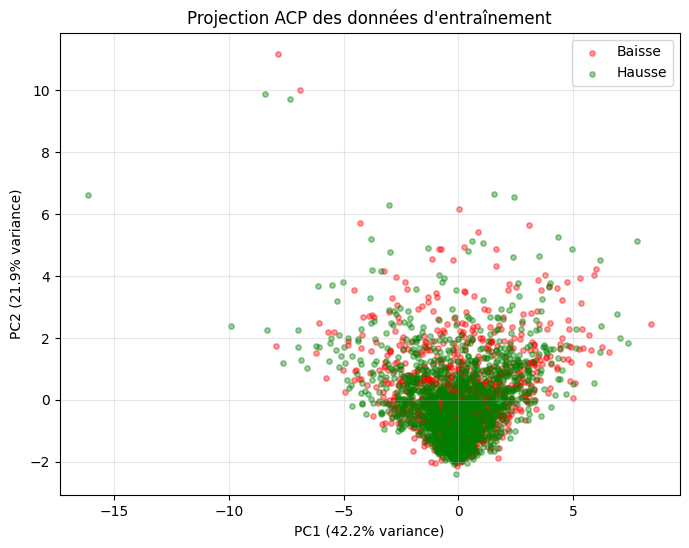

Variance expliquée par les 2 premières composantes : 64.2%


In [358]:
#fait l'ACP
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_sc)

print(X_train_pca)

#affiche l'ACP
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1],
           c='red', alpha=0.4, s=15, label='Baisse') #point baisse en rouge
ax.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1],
           c='green', alpha=0.4, s=15, label='Hausse') # point hausse en vert
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Projection ACP des données d'entraînement")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Variance expliquée par les 2 premières composantes : {pca.explained_variance_ratio_.sum():.1%}")

On observe que les classes "hausse" et "baisse" se chevauchent fortement dans l'espace ACP. Il n'y a pas de séparation linéaire évidente, ce qui annonce que les modèles auront probablement du mal à atteindre de bon résultats.

## 7. Modèles

Nous comparons plusieurs modèles, du plus simple au plus complexe :

1. **Baseline naïf** : prédit toujours la classe majoritaire ("hausse")
2. **Régression logistique** : modèle linéaire de référence pour la classification binaire
3. **Régression logistique pénalisée Ridge** ($\ell_2$) : ajoute une pénalité $\lambda \|\beta\|_2^2$
4. **Régression logistique pénalisée Lasso** ($\ell_1$) : ajoute une pénalité $\lambda \|\beta\|_1$, qui sélectionne automatiquement les features
5. **K plus proches voisins (KNN)** : modèle non paramétrique

Pour le choix des hyperparamètres ($\lambda$ pour les modèles pénalisés, $k$ pour KNN), on utilise une **validation croisée temporelle** (`TimeSeriesSplit`), qui respecte l'ordre chronologique.

In [359]:
# Validation croisée respectant l'ordre temporel
tscv = TimeSeriesSplit(n_splits=5)

# Dictionnaire pour stocker les résultats des modèles
resultats = {}

### 7.1 Baseline naïf

On prédit toujours la hausse.

In [360]:
classe_majoritaire = int(np.round(y_train.mean()))
y_pred_baseline = np.full_like(y_test, classe_majoritaire)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Classe majoritaire : {classe_majoritaire} ({'Hausse' if classe_majoritaire == 1 else 'Baisse'})")
print(f"Accuracy baseline (test) : {acc_baseline:.4f}")

resultats['Baseline'] = acc_baseline

Classe majoritaire : 1 (Hausse)
Accuracy baseline (test) : 0.4564


Un modèle a donc de l'intérêt seulement s'il a une accuracy au moins supérieure à 0.4966.

### 7.2 Régression logistique

**Rappel théorique.** La régression logistique modélise la probabilité d'appartenir à la classe 1 par :
$$ P(y = 1 \mid x) = \sigma(\beta^T x) = \frac{1}{1 + e^{-\beta^T x}} $$

Les paramètres $\beta$ sont estimés en **maximisant la log-vraisemblance**, ce qui revient à **minimiser la log-loss** (entropie croisée binaire) :
$$ \mathcal{L}(\beta) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \log \sigma(\beta^T x_i) + (1 - y_i) \log(1 - \sigma(\beta^T x_i)) \right] $$

L'optimisation se fait par des méthodes itératives (par défaut **L-BFGS** dans scikit-learn).

In [361]:
logreg = LogisticRegression(penalty=None, max_iter=2000)
logreg.fit(X_train_sc, y_train)

y_pred_logreg = logreg.predict(X_test_sc)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Accuracy régression logistique (test) : {acc_logreg:.4f}")

resultats['Logistique'] = acc_logreg

# Coefficients appris
coefs = pd.DataFrame({'feature': FEATURES, 'coef': logreg.coef_[0]})
coefs['|coef|'] = coefs['coef'].abs()
print("\nCoefficients appris (triés par importance) :")
print(coefs.sort_values('|coef|', ascending=False).to_string(index=False))

Accuracy régression logistique (test) : 0.5369

Coefficients appris (triés par importance) :
   feature      coef   |coef|
  return_1 -0.195023 0.195023
  vol_norm  0.077906 0.077906
 return_10 -0.076100 0.076100
ecart_MA20  0.073788 0.073788
  return_2  0.045127 0.045127
    vol_20  0.042510 0.042510
     vol_5 -0.029521 0.029521
  return_5 -0.018380 0.018380


### 7.3 Régression logistique pénalisée Ridge

**Rappel théorique.** Pour limiter le sur-apprentissage et stabiliser les coefficients, on ajoute une pénalité $\ell_2$ :
$$ \hat{\beta} = \arg\min_\beta \; \mathcal{L}(\beta) + \lambda \|\beta\|_2^2 $$

Dans scikit-learn, le paramètre est `C = 1/λ` : un petit `C` correspond à une forte régularisation.

On choisit $\lambda$ par **validation croisée temporelle**.

In [362]:
logreg_ridge = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 20),
    cv=tscv,
    penalty='l2',
    solver='lbfgs',
    scoring='accuracy',
    max_iter=2000,
)
logreg_ridge.fit(X_train_sc, y_train)

y_pred_ridge = logreg_ridge.predict(X_test_sc)
acc_ridge = accuracy_score(y_test, y_pred_ridge)

print(f"Meilleur C (= 1/λ)  : {logreg_ridge.C_[0]:.4f}")
print(f"Accuracy Ridge (test) : {acc_ridge:.4f}")

resultats['Logistique Ridge'] = acc_ridge

Meilleur C (= 1/λ)  : 0.0043
Accuracy Ridge (test) : 0.5503


### 7.4 Régression logistique pénalisée Lasso

**Rappel théorique.** La pénalité Lasso utilise la norme $\ell_1$ :
$$ \hat{\beta} = \arg\min_\beta \; \mathcal{L}(\beta) + \lambda \|\beta\|_1 $$

Contrairement à Ridge, Lasso a la propriété intéressante de mettre certains coefficients **exactement à zéro**, ce qui revient à faire une **sélection de variables automatique**.

In [363]:
logreg_lasso = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 20),
    cv=tscv,
    penalty='l1',
    solver='liblinear',
    scoring='accuracy',
    max_iter=2000,
)
logreg_lasso.fit(X_train_sc, y_train)

y_pred_lasso = logreg_lasso.predict(X_test_sc)
acc_lasso = accuracy_score(y_test, y_pred_lasso)

print(f"Meilleur C (= 1/λ)  : {logreg_lasso.C_[0]:.4f}")
print(f"Accuracy Lasso (test) : {acc_lasso:.4f}")

# Quelles features ont été sélectionnées ?
coefs_lasso = pd.DataFrame({'feature': FEATURES, 'coef': logreg_lasso.coef_[0]})
n_selected = (coefs_lasso['coef'] != 0).sum()
print(f"\nFeatures sélectionnées par Lasso : {n_selected} / {len(FEATURES)}")
print(coefs_lasso[coefs_lasso['coef'] != 0].sort_values('coef', key=abs, ascending=False).to_string(index=False))

resultats['Logistique Lasso'] = acc_lasso

Meilleur C (= 1/λ)  : 0.0785
Accuracy Lasso (test) : 0.5302

Features sélectionnées par Lasso : 2 / 8
 feature      coef
return_1 -0.149451
vol_norm  0.049527


### 7.5 K plus proches voisins (KNN)

**Rappel théorique.** Pour prédire la classe d'un nouveau point $x$, KNN cherche les $k$ points les plus proches (au sens de la distance euclidienne) dans le jeu d'entraînement et prédit la classe majoritaire parmi ces voisins.

C'est un modèle **non paramétrique** : il n'apprend pas de paramètres explicites, il stocke simplement les données d'entraînement. Le seul hyperparamètre est $k$, qu'on choisit par validation croisée.

In [364]:
param_grid = {'n_neighbors': [3, 5, 10, 15, 20, 30, 50, 75, 100]}

knn_cv = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=tscv,
    scoring='accuracy',
)
knn_cv.fit(X_train_sc, y_train)

y_pred_knn = knn_cv.predict(X_test_sc)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Meilleur k : {knn_cv.best_params_['n_neighbors']}")
print(f"Accuracy KNN (test) : {acc_knn:.4f}")

resultats['KNN'] = acc_knn

Meilleur k : 50
Accuracy KNN (test) : 0.5839


## 8. Comparaison et choix du modèle final

          Modèle  Accuracy test
             KNN       0.583893
Logistique Ridge       0.550336
      Logistique       0.536913
Logistique Lasso       0.530201
        Baseline       0.456376


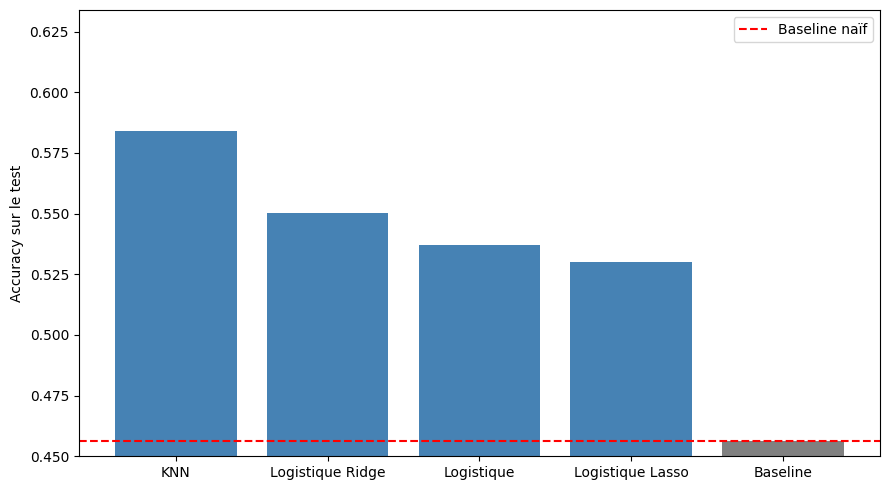

In [365]:
# Récapitulatif des accuracies
df_resultats = pd.DataFrame({
    'Modèle': list(resultats.keys()),
    'Accuracy test': list(resultats.values()),
}).sort_values('Accuracy test', ascending=False).reset_index(drop=True)

print(df_resultats.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['gray' if m == 'Baseline' else 'steelblue' for m in df_resultats['Modèle']]
ax.bar(df_resultats['Modèle'], df_resultats['Accuracy test'], color=colors)
ax.axhline(acc_baseline, color='red', linestyle='--', label='Baseline naïf')
ax.set_ylabel('Accuracy sur le test')
ax.set_ylim(0.45, max(df_resultats['Accuracy test']) + 0.05)
ax.legend()
plt.tight_layout()
plt.show()


**Choix du modèle final:** On choisit le modèle qui obtient la meilleure accuracy sur le test.

In [366]:
modeles_dispo = {
    'Logistique': logreg,
    'Logistique Ridge': logreg_ridge,
    'Logistique Lasso': logreg_lasso,
    'KNN': knn_cv.best_estimator_,
}

best_name = max(modeles_dispo, key=lambda m: resultats[m])
best_model = modeles_dispo[best_name]

print(f"Modèle final choisi : {best_name}, accuracy : {resultats[best_name]:.4f}")


Modèle final choisi : KNN, accuracy : 0.5839


## 9. Évaluation détaillée du modèle final

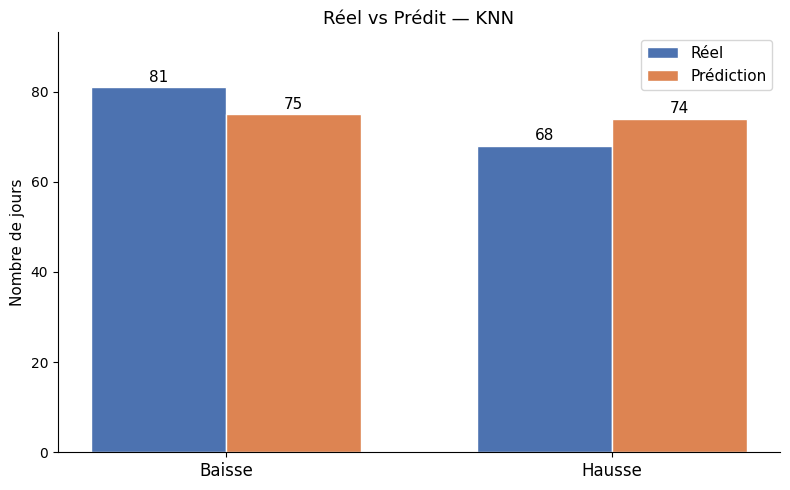


Rapport de classification :
              precision    recall  f1-score   support

      Baisse       0.63      0.58      0.60        81
      Hausse       0.54      0.59      0.56        68

    accuracy                           0.58       149
   macro avg       0.58      0.58      0.58       149
weighted avg       0.59      0.58      0.58       149



In [367]:
y_pred_final = best_model.predict(X_test_sc)

categories = ['Baisse', 'Hausse']
reel = [(y_test == 0).sum(), (y_test == 1).sum()]
predit = [(y_pred_final == 0).sum(), (y_pred_final == 1).sum()]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, reel, width, label='Réel', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, predit, width, label='Prédiction', color='#DD8452', edgecolor='white')

# Valeurs au dessus des barres
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Nombre de jours', fontsize=11)
ax.set_title(f'Réel vs Prédit — {best_name}', fontsize=13)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(reel + predit) * 1.15)
plt.tight_layout()
plt.show()

print('\nRapport de classification :')
print(classification_report(y_test, y_pred_final, target_names=['Baisse', 'Hausse']))


## 10. Conclusion

En ajustant les paramètres des modèles et en travaillant sur la sélection des features, on arrive à une accuracy d'environ 0.58 sur le jeu de test avec le KNN. C'est un résultat correct, mais qui demande à être nuancé.

### Les limites du modèle

La première chose à rappeler, c'est qu'en finance, les performances passées n'indiquent en rien les performances futures. Un modèle qui aurait bien fonctionné sur 2018-2024 n'a aucune garantie de tenir sur les années suivantes, surtout sur un marché aussi instable que le Bitcoin.

Ensuite, les données financières ne sont pas linéaires. Le cours du Bitcoin est influencé par des dizaines de facteurs difficilement quantifiables : décisions politiques, faillites d'exchanges, sentiment collectif sur les réseaux... Les modèles qu'on a utilisés (régression logistique, KNN) sont relativement simples et ont du mal à capturer ces dynamiques complexes.

Notre dataset a aussi ses limites : on travaille uniquement sur la pool BTC/USDT de Binance, qui comme on l'a vu n'est plus très représentative au niveau du volume après 2023 — les prix eux restent fiables et cohérents avec le reste du marché. On n'utilise par ailleurs que des données intrinsèques au Bitcoin (prix et volume), alors que les vrais algorithmes de trading intègrent aussi des données exogènes comme le sentiment sur les réseaux sociaux, les actualités macroéconomiques ou les flux de capitaux institutionnels.

Enfin, même un modèle à 58% d'accuracy ne serait pas nécessairement profitable en pratique à cause des frais de transaction, du slippage et du spread.

### Ce qu'on peut en retenir

À partir de simples données de prix et de volume, on arrive quand même à faire légèrement mieux qu'un modèle naïf de manière consistante. C'est modeste mais pas sans intérêt : ça suggère qu'il existe des patterns dans les données historiques, même si leur exploitation reste limitée avec les outils utilisés ici. Pour aller plus loin il faudrait enrichir les données avec des indicateurs externes et potentiellement utiliser des modèles plus adaptés aux séries temporelles non linéaires.


## 11. Test de généralisation sur d'autres cryptomonnaies

Une question intéressante : le modèle entraîné sur Bitcoin se généralise-t-il à d'autres cryptomonnaies ? Si oui, cela suggérerait l'existence de **dynamiques communes** au marché crypto. Si non, chaque actif a sa propre dynamique.

On utilise la bibliothèque `yfinance` pour récupérer les données ETH-USD et SOL-USD. (Si elle n'est pas installée : `pip install yfinance`.)

In [368]:
try:
    import yfinance as yf
    YF_OK = True
except ImportError:
    YF_OK = False
    print("yfinance non installé. Lancer : pip install yfinance")

In [369]:
def telecharger_crypto(ticker, start='2019-01-01', end='2025-01-01'):
    """Télécharge les données journalières d'une crypto et les met au format de notre dataset."""
    raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.reset_index()
    raw = raw.rename(columns={'Date': 'Date'})
    raw['Date'] = pd.to_datetime(raw['Date'])
    return raw[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

def evaluer_sur_crypto(ticker, modele, scaler, features):
    """Télécharge les données d'une crypto, applique le même feature engineering,
    et évalue le modèle déjà entraîné sur BTC."""
    df_c = telecharger_crypto(ticker)
    df_c = construire_features(df_c).dropna(subset=features + ['y']).reset_index(drop=True)
    Xc = scaler.transform(df_c[features].values)
    yc = df_c['y'].values
    pred = modele.predict(Xc)
    return accuracy_score(yc, pred), yc.mean()

if YF_OK:
    cryptos_test = ['ETH-USD', 'SOL-USD', 'BNB-USD']
    print(f"{'Crypto':<10} {'Accuracy':>10} {'% hausse':>10}")
    print('-' * 32)
    for tk in cryptos_test:
        try:
            acc, taux = evaluer_sur_crypto(tk, best_model, scaler, FEATURES)
            print(f"{tk:<10} {acc:>10.4f} {taux:>10.2%}")
        except Exception as e:
            print(f"{tk:<10} erreur : {e}")

Crypto       Accuracy   % hausse
--------------------------------
ETH-USD        0.5299     51.80%
SOL-USD        0.5067     49.97%
BNB-USD        0.5304     52.30%
